In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
import os
import glob


# Target the Sharepoint Folder

In [9]:
# Get the base user profile (handles Drew.Quinton vs any other user)
home = os.path.expanduser("~")

# Define the potential OneDrive/SharePoint root folders
# Different machines might use "OneDrive - DOT OST" or just "OneDrive"
roots = [
    os.path.join(home, "OneDrive - DOT OST"),
    os.path.join(home, "OneDrive - USDOT"),
    os.path.join(home, "DOT"),
]

for root in roots:
    if os.path.exists(root):
        # Use a "recursive glob" to find the specific target folder.
        # This looks for 'Daily Feed Pull' anywhere inside the OneDrive folder,
        # ignoring whatever renamed shortcut lies in between.
        search_pattern = os.path.join(root, "**", "Daily Feed Pull")
        matches = glob.glob(search_pattern, recursive=True)
        
        if matches:
            # Return the first match found
            daily_feed_pull_folder = Path(matches[0])
        else:
            from tkinter import filedialog, Tk
            root = Tk()
            root.withdraw() # Hide the tiny white window
            daily_feed_pull_folder = Path(filedialog.askdirectory(title="Please select the 'Daily Feed Pull' folder"))

# Create Dataframes

In [10]:
closure_file_list = [
    f for f in daily_feed_pull_folder.iterdir() 
    if f.is_file() and f.name.endswith('_Road_Closure_Feed.csv')
]

if closure_file_list:
    closures_df = pd.concat([pd.read_csv(f) for f in closure_file_list], ignore_index=True)
    print(f"Merged {len(closure_file_list)} Road Closure Feed files into 'closures_df'.")
else:
    print("No matching files found.")
    
alerts_file_list = [
    f for f in daily_feed_pull_folder.iterdir() 
    if f.is_file() and f.name.endswith('_alerts_feed.csv')
]

if alerts_file_list:
    alerts_df = pd.concat([pd.read_csv(f) for f in alerts_file_list], ignore_index=True)
    print(f"Merged {len(alerts_file_list)} Alerts Feed files in 'alerts_df'.")
else:
    print("No matching files found.")

Merged 61 Road Closure Feed files into 'closures_df'.
Merged 61 Alerts Feed files in 'alerts_df'.


In [ ]:
# closures_df.to_csv('Closures.csv', index=False)
# alerts_df.to_csv('Alerts.csv', index=False)

# Closure Feed Analysis

### Number of Closures Over Time

In [11]:
closure_count_by_park = pd.pivot_table(
    closures_df,
    values='core_details.event_type',
    index = 'organization_name',
    columns='extraction_date',
    aggfunc='count'
)
closure_count_by_park = closure_count_by_park.fillna(0).astype(int)
closure_count_by_park

extraction_date,2026-03-13,2026-03-14,2026-03-15,2026-03-16,2026-03-17,2026-03-18,2026-03-19,2026-03-20,2026-03-21,2026-03-22,...,2026-05-05,2026-05-06,2026-05-07,2026-05-08,2026-05-09,2026-05-10,2026-05-11,2026-05-12,2026-05-13,2026-05-14
organization_name,,,,,,,,,,,,,,,,,,,,,
Acadia National Park,0,0,0,0,0,0,0,0,0,0,...,3,3,3,3,3,3,3,3,3,3
Black Canyon of the Gunnison National Park,8,8,8,0,8,8,8,8,8,8,...,0,0,0,0,0,0,0,0,0,0
Blue Ridge Parkway,20,20,20,20,70,70,70,72,72,72,...,0,0,0,0,0,0,0,0,0,0
Buffalo National River,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Canyonlands National Park,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Chickamauga & Chattanooga,0,0,0,0,0,0,0,0,0,0,...,4,4,4,4,4,4,4,4,4,4
Crater Lake National Park,10,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,8,8,8
Curecanti National Recreation Area,2,2,2,0,2,2,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
Delaware Water Gap,18,18,18,0,18,18,18,18,18,18,...,14,14,14,14,14,14,14,14,14,14


In [5]:
count = closures_df['extraction_date'].nunique()
print(f'{count} days of daily pulls')

61 days of daily pulls


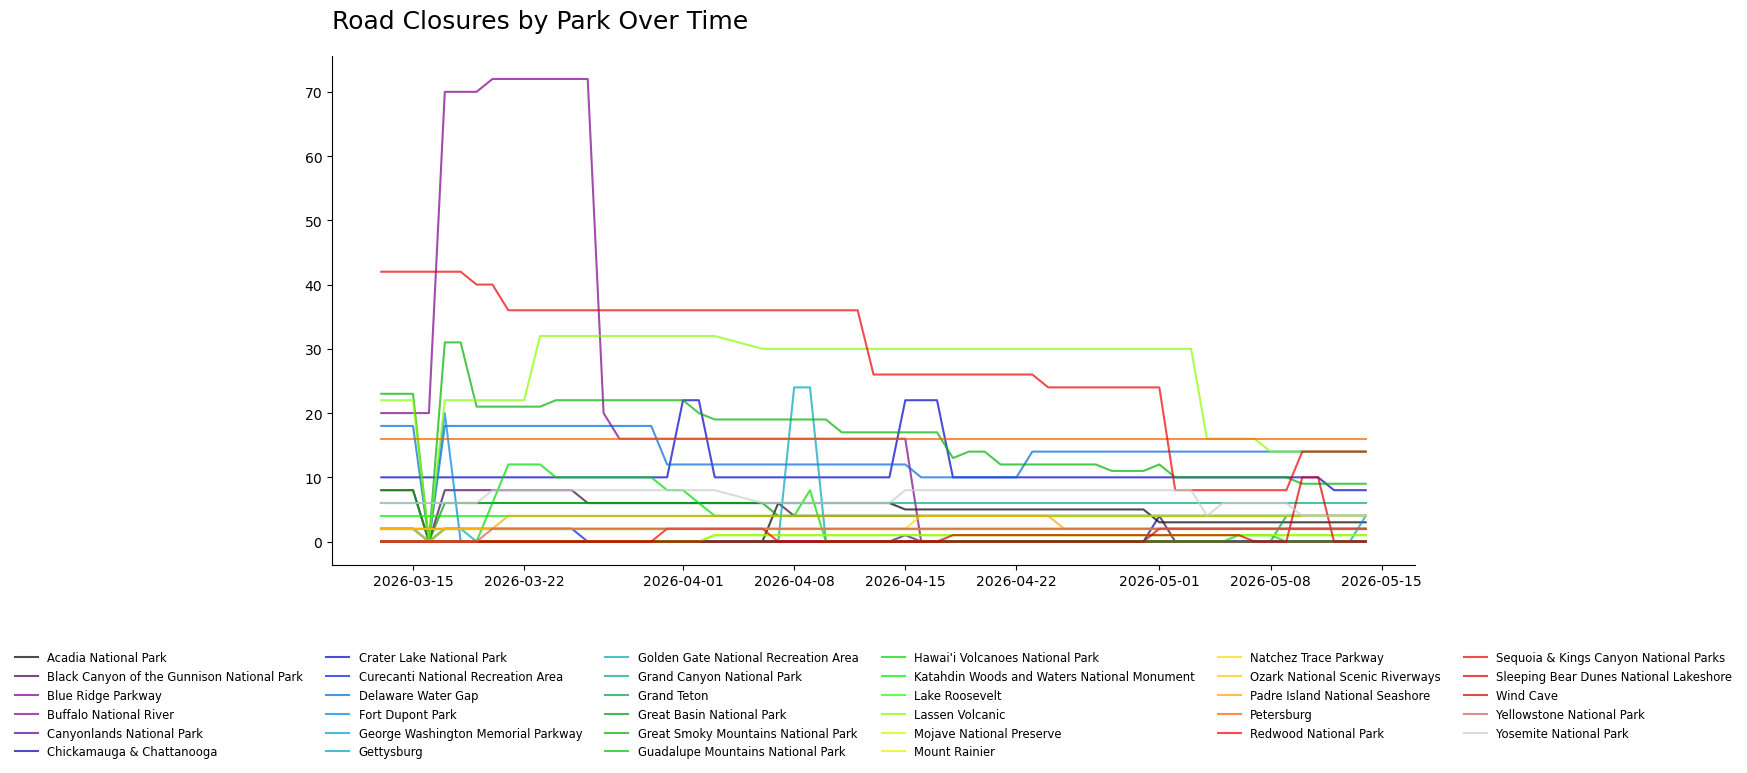

In [ ]:
plt.figure(figsize=(16, 8)) # Increased width for "full screen" feel
df_plot = closure_count_by_park 
df_plot.index = pd.to_datetime(df_plot.index)

colors = cm.nipy_spectral(np.linspace(0, 1, len(df_plot.columns)))

for i, column in enumerate(df_plot.columns):
    plt.plot(df_plot.index, df_plot[column], 
             color=colors[i], linewidth=1.5, alpha=0.7, label=column)

# move legend to bottom
plt.legend(loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), 
           ncol=6,            # Spread the 30 items across 6 columns
           fontsize='small', 
           frameon=False)

plt.title("Road Closures by Park Over Time", loc='left', fontsize=18, pad=20)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout() 

plt.show()

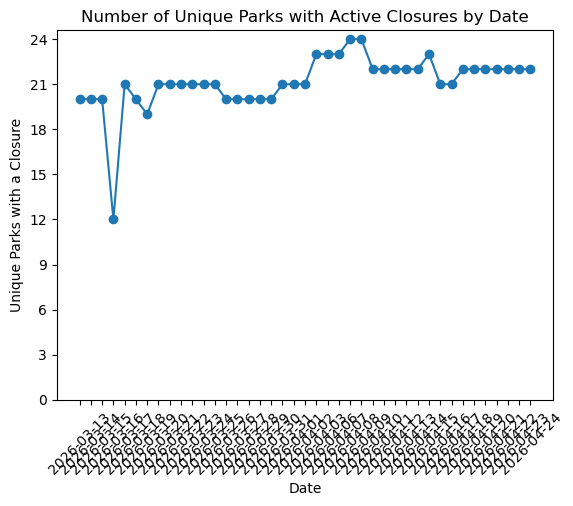

In [27]:
unique_parks_per_day = closures_df.groupby('extraction_date')['organization_name'].nunique()
unique_parks_per_day = pd.DataFrame(unique_parks_per_day)
unique_parks_per_day = unique_parks_per_day.reset_index()

plt.plot(unique_parks_per_day['extraction_date'], unique_parks_per_day['organization_name'], marker='o', linestyle='-')

plt.xlabel('Date')
plt.ylabel('Unique Parks with a Closure')
plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True)) # Force Y-axis to only show whole numbers (integers)
plt.title('Number of Unique Parks with Active Closures by Date')
plt.xticks(rotation=45)

plt.show()

# Alerts Feed Analysis

### Number of Alerts Over Time

In [28]:
alerts_count_by_park = pd.pivot_table(
    alerts_df,
    values='id',
    index = 'parkCode',
    columns='extraction_date',
    aggfunc='count'
)
alerts_count_by_park = alerts_count_by_park.fillna(0).astype(int)
alerts_count_by_park

extraction_date,2026-03-13,2026-03-14,2026-03-15,2026-03-16,2026-03-17,2026-03-18,2026-03-19,2026-03-20,2026-03-21,2026-03-22,...,2026-04-15,2026-04-16,2026-04-17,2026-04-18,2026-04-19,2026-04-20,2026-04-21,2026-04-22,2026-04-23,2026-04-24
parkCode,,,,,,,,,,,,,,,,,,,,,
abli,0,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
acad,1,1,1,1,2,2,3,3,3,3,...,4,4,4,4,4,4,4,4,4,4
adam,3,3,3,3,3,3,3,3,3,3,...,2,2,2,2,2,2,2,2,2,2
afbg,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
agfo,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
yell,4,4,4,3,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,4
york,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
yose,1,1,1,1,1,1,1,1,1,1,...,2,2,2,2,2,2,2,2,2,2
